# Sandpiles Project
### COMP90072 Art of Scientific Computation
### Jonathan Purcell

In [ ]:
from sandpiles import *

## Simulations

In [ ]:
n_steps = 1_000_000
shape = (5, 5)

sim = simulate_sandpiles(shape, n_steps, seed=1)

NotDefinedError: Failed in nopython mode pipeline (step: nopython frontend)
[1m[1mFailed in nopython mode pipeline (step: nopython frontend)
[1m[1m[1mFailed in nopython mode pipeline (step: inline calls to locally defined closures)
[1m[1mThe compiler failed to analyze the bytecode. Variable 'qtail' is not defined.
[1m
File "sandpiles\simulation.py", line 101:[0m
[1m    def topple_helper(x, y):
        <source elided>
            if board[x, y] == 4:
[1m                queue[qtail, 0] = x
[0m                [1m^[0m[0m
[0m
[0m[1mDuring: Pass inline_closure_likes[0m
[0m[1mDuring: resolving callee type: type(CPUDispatcher(<function _simulate_topple at 0x000001E9E0EC2CF0>))[0m
[0m[1mDuring: typing of call at c:\Users\purce\OneDrive\Documents\1- Graduate Studies\COMP90072 The Art of Scientific Computation\report\jdpurcell\project\sandpiles\simulation.py (62)[0m
[0m[1mDuring: Pass nopython_type_inference[0m
[0m[1mDuring: resolving callee type: type(CPUDispatcher(

: 

In [1]:
from importlib import reload
import sandpiles
reload(sandpiles)

import numpy as np
import matplotlib.pyplot as plt

In [2]:
sandpile = sandpiles.Simulation(
    shape= (5, 5), 
    n_steps=1_000_000,
    seed = 1
    )  

100%|██████████| 1000000/1000000 [00:14<00:00, 68455.97it/s]


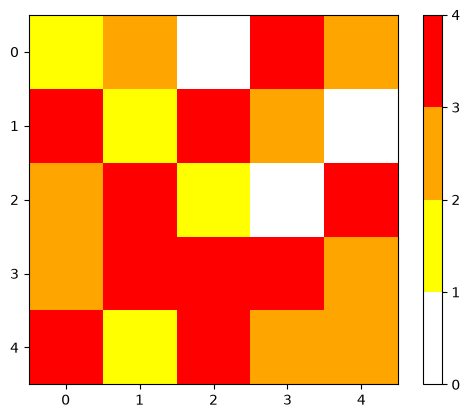

In [3]:
sandpiles.visualise_board(sandpile.board)

## Sandpile Topples

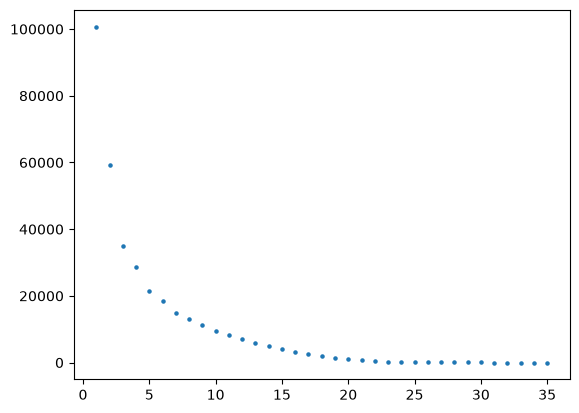

In [9]:
sandpiles.visualise_statistic(sandpile.topples, s=5)


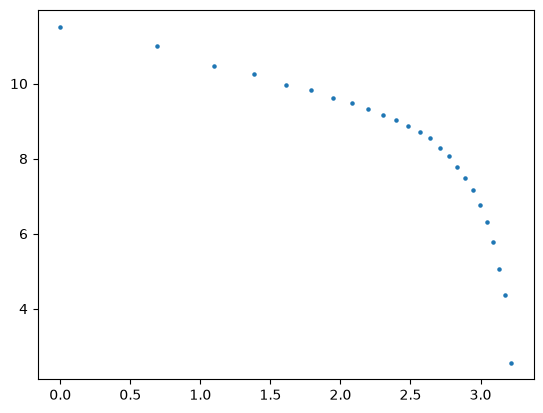

In [10]:
sandpiles.visualise_statistic(sandpile.area, log=True, s=5)

We model the distribution of topples as an approximate power-law relationship with an exponential truncation factor to 

In [4]:
from importlib import reload
import sandpiles
reload(sandpiles)
s = sandpiles.compute_powerlaw_MLEs(
    sandpile.topples
)
s

1.131319698910353
-8.30971668637427 0.56135870581582 1.13062335846507


mpf('1.6215194013783797')

In [5]:
from importlib import reload
import sandpiles
reload(sandpiles)
s = sandpiles.compute_powerlaw_MLEs(
    sandpile.topples[sandpile.topples < np.exp(2)]
)
s

0.7750633606943004
-8.66597302459033 0.205102367599768 0.774367020249016


mpf('1.8147341269003432')

In [7]:
from importlib import reload
import sandpiles
reload(sandpiles)
sandpiles.compute_exp_trunc_pwr_mles(sandpile.topples[sandpile.topples > 0])

[2.  0.1] -1064837.665156402
[2.00000001 0.1       ] -1064837.6679617434
[2.         0.10000001] -1064837.6754742772
[1.00124766 0.05006238] -875968.2153201189
[1.00124767 0.05006238] -875968.2150794953
[1.00124766 0.05006239] -875968.2091656699
[0.91824856 0.09865748] -865289.0598985612
[0.91824857 0.09865748] -865289.0604018596
[0.91824856 0.09865749] -865289.0608753671
[0.71119807 0.11945813] -859157.3491369784
[0.71119808 0.11945813] -859157.3493171816
[0.71119807 0.11945814] -859157.3490602615
[0.50478882 0.14582955] -856971.1401054702
[0.50478883 0.14582955] -856971.1400528904
[0.50478882 0.14582956] -856971.1395094288
[0.46507925 0.15426014] -856754.8089876026
[0.46507926 0.15426014] -856754.80893914
[0.46507925 0.15426015] -856754.8085920352
[0.44109    0.16178835] -856651.764739413
[0.44109001 0.16178835] -856651.7647262367
[0.44109    0.16178836] -856651.7646615375
[0.44104878 0.16264335] -856648.1787872722
[0.44104879 0.16264335] -856648.1787856969
[0.44104878 0.16264336] -8

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 856648.1349246232
        x: [ 4.417e-01  1.626e-01]
      nit: 9
      jac: [ 9.313e-02  4.238e+00]
     nfev: 30
     njev: 10
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

This looks like a power-law relationship.

Denote by $n_t(s)$ the number of topples of size $s$.

If $n_t(s) = \alpha s ^\beta$ then $\ln(n_t(s)) = \ln(\alpha) + s \ln (\beta)$.

Then, we can find $\ln (\alpha)$ and $\ln(\beta)$ via least-squares fit:

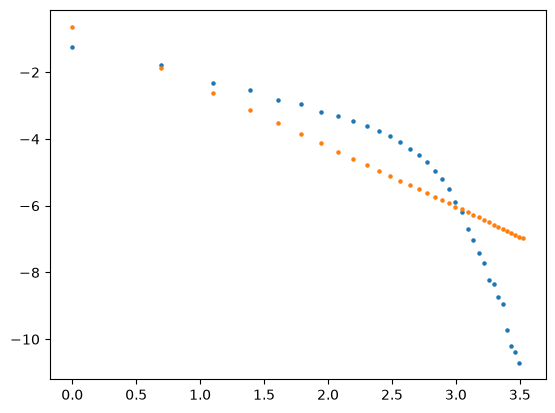

In [38]:
import mpmath

nonzero_topples = sandpile.topples[sandpile.topples > 0]
t_size, t_count = np.unique(nonzero_topples, return_counts = True)
log_t_size = np.log(t_size)
log_t_count = np.log(t_count / nonzero_topples.size)

plt.scatter(log_t_size, log_t_count, s=5)

s = 1.8
x = np.arange(1, 35)
logx = np.log(x)
logpdf = -np.log(float(mpmath.zeta(s, derivative=0))) - s*logx

plt.scatter(logx, logpdf, s=5)


c:\Users\purce\OneDrive\Documents\1- Graduate Studies\COMP90072 The Art of Scientific Computation\project\sandpiles.py:136: RuntimeWarning: divide by zero encountered in log
  stat = np.log(stat)


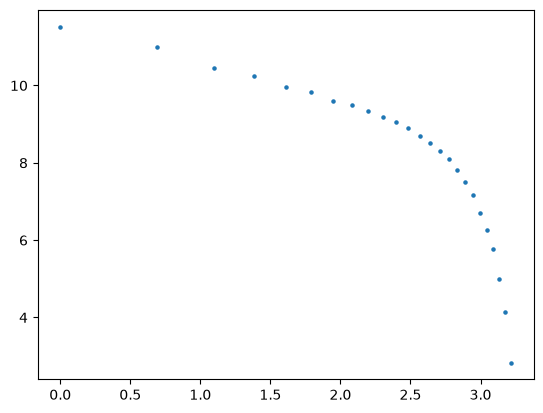

In [70]:
sandpiles.visualise_statistic(sandpile.area, log=True, s=5)